Se procederá a realizar el entrenamiento de un modelo predictivo para el caso de estudio:

In [1]:
import pandas as pd

ventas_mensuales = pd.read_csv("ventas_mensuales_limpio.csv", parse_dates=["fecha"])

SELECCIÓN DE VARIABLES:

In [2]:
#Y es target
#X es predictora

# X: Variables que usamos para predecir
X = ventas_mensuales[["mes_n", "media_3m", "producto_cod", "categoria_cod", "medida_cod"]]

# y: Variable que queremos predecir
y = ventas_mensuales["cantidad"]

In [3]:
print(X.dtypes)

mes_n              int64
media_3m         float64
producto_cod       int64
categoria_cod      int64
medida_cod         int64
dtype: object


Procedemos con el código para entrenar el modelo (Primero probaré regresión lineal)

In [4]:
# Paso 0: Tener mis variables listas
# X = ventas_mensuales[["mes_n", "media_3m", "mes", "año", "producto_cod", "categoria_cod", "medida_cod"]]
# y = ventas_mensuales["cantidad"]

# Paso 1: Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Paso 2: Escalado (opcional pero recomendado)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Paso 3: Entrenar modelo (Regresión Lineal)
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# Paso 4: Predecir
y_pred = modelo.predict(X_test_scaled)

# Paso 5: Evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Métricas del modelo:")
print(f"➡️  Error cuadrático medio (MSE): {mse:.2f}")
print(f"➡️  Error absoluto medio (MAE): {mae:.2f}")
print(f"➡️  R2 (explicación de la varianza): {r2:.2f}")


📊 Métricas del modelo:
➡️  Error cuadrático medio (MSE): 991.86
➡️  Error absoluto medio (MAE): 25.87
➡️  R2 (explicación de la varianza): 0.60


📈 Visualizar el rendimiento
Gráfico comparando predicciones vs valores reales:

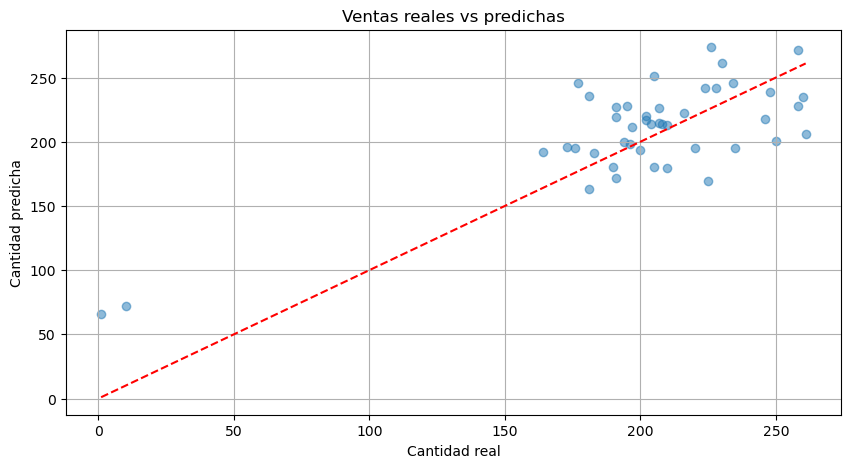

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Cantidad real")
plt.ylabel("Cantidad predicha")
plt.title("Ventas reales vs predichas")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea perfecta
plt.grid(True)
plt.savefig("grafico_pred_vs_real.png", dpi=300, bbox_inches='tight')
plt.show()



Ahora probaré un modelo de regresión no lineal, Random Forest

In [6]:
# Paso 0: Tener mis variables listas
# Asegúrate de tener definidas X e y
# X = ventas_mensuales[["mes_n", "media_3m", "mes", "año", "producto_cod", "categoria_cod", "medida_cod"]]
# y = ventas_mensuales["cantidad"]

# Paso 1: Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Paso 2: Escalado (NO necesario para Random Forest, pero puedes hacerlo si deseas comparar con otros modelos)
# Aquí lo omitimos para mantenerlo más simple

# Paso 3: Entrenar modelo (Regresión No Lineal)
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Paso 4: Predecir
y_pred = modelo.predict(X_test)

# Paso 5: Evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Métricas del modelo (Random Forest):")
print(f"➡️  Error cuadrático medio (MSE): {mse:.2f}")
print(f"➡️  Error absoluto medio (MAE): {mae:.2f}")
print(f"➡️  R2 (explicación de la varianza): {r2:.2f}")


📊 Métricas del modelo (Random Forest):
➡️  Error cuadrático medio (MSE): 785.29
➡️  Error absoluto medio (MAE): 22.68
➡️  R2 (explicación de la varianza): 0.68


Evaluación gráfica:

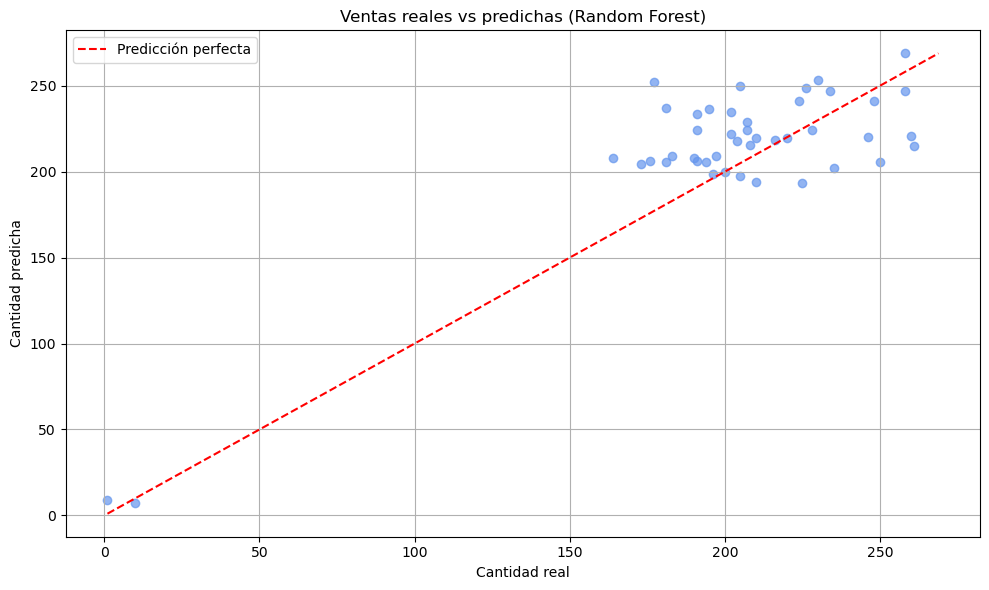

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Crear figura
plt.figure(figsize=(10, 6))

# Dispersión de valores reales vs predichos
plt.scatter(y_test, y_pred, alpha=0.7, color='cornflowerblue')

# Línea de referencia (perfecta predicción)
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

# Etiquetas
plt.xlabel("Cantidad real")
plt.ylabel("Cantidad predicha")
plt.title("Ventas reales vs predichas (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Usaré otro modelo para la predicción: XGboost

In [9]:
# Paso 0: Tener mis variables listas
# X = ventas_mensuales[["mes_n", "media_3m", "mes", "año", "producto_cod", "categoria_cod", "medida_cod"]]
# y = ventas_mensuales["cantidad"]

# Paso 1: Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Paso 2: Escalado (opcional con XGBoost, pero puedes hacerlo si quieres)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Paso 3: Entrenar modelo XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

# Paso 4: Predecir
y_pred = xgb_model.predict(X_test_scaled)

# Paso 5: Evaluar el modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Métricas del modelo (XGBoost):")
print(f"➡️  Error cuadrático medio (MSE): {mse:.2f}")
print(f"➡️  Error absoluto medio (MAE): {mae:.2f}")
print(f"➡️  R2 (explicación de la varianza): {r2:.2f}")


📊 Métricas del modelo (XGBoost):
➡️  Error cuadrático medio (MSE): 822.61
➡️  Error absoluto medio (MAE): 22.70
➡️  R2 (explicación de la varianza): 0.67


Evaluación gráfica:

/tmp/ipykernel_2284/3303839539.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2284/3303839539.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("grafico_xgboost_pred_vs_real.png", dpi=300)
/home/arizael/anaconda3/envs/DataScience/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


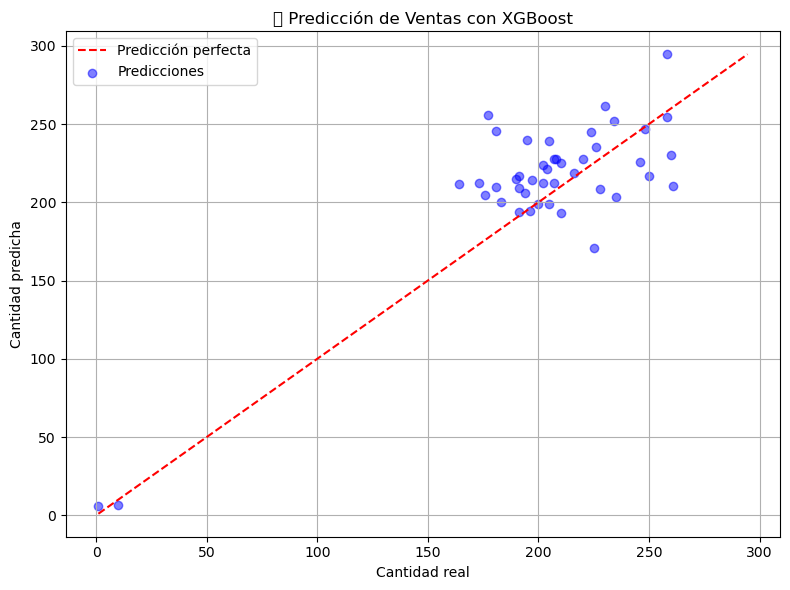

In [10]:
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(8, 6))

# Línea de referencia: predicción perfecta
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

# Puntos de datos
plt.scatter(y_test, y_pred, alpha=0.5, color="blue", label="Predicciones")

# Estética
plt.xlabel("Cantidad real")
plt.ylabel("Cantidad predicha")
plt.title("📊 Predicción de Ventas con XGBoost")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar y guardar
plt.savefig("grafico_xgboost_pred_vs_real.png", dpi=300)
plt.show()


Comparaciones hasta el momento de los 3 modelos probados:
Métricas del modelo (LinearRegression):
➡️  Error cuadrático medio (MSE): 991.86
➡️  Error absoluto medio (MAE): 25.87
➡️  R2 (explicación de la varianza): 0.60

Métricas del modelo (Random Forest):
➡️  Error cuadrático medio (MSE): 785.29
➡️  Error absoluto medio (MAE): 22.68
➡️  R2 (explicación de la varianza): 0.68

Métricas del modelo (XGBoost):
➡️  Error cuadrático medio (MSE): 822.61
➡️  Error absoluto medio (MAE): 22.70
➡️  R2 (explicación de la varianza): 0.67

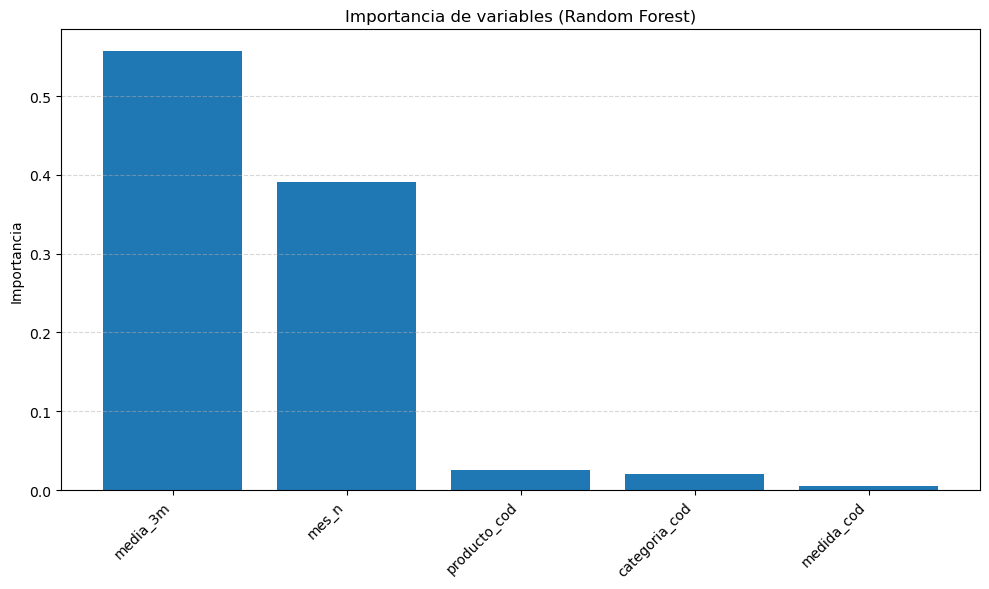

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegúrate de haber entrenado el modelo Random Forest como "modelo"
# Y que X tenga los nombres de las columnas usadas
importances = modelo.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]  # Orden descendente

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.title("Importancia de variables (Random Forest)")
plt.bar(range(len(features)), importances[indices], align='center')
plt.xticks(range(len(features)), features[indices], rotation=45, ha="right")
plt.ylabel("Importancia")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [13]:
# Paso 0: Redefinir X con solo las variables importantes
X_reducido = X[["media_3m", "mes_n"]]

# Paso 1: Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reducido, y, test_size=0.2, random_state=42
)

# Paso 2: Escalar (opcional, no obligatorio para Random Forest, pero lo dejamos fuera por simplicidad)
# Random Forest no requiere escalado, así que usamos los datos tal cual.

# Paso 3: Entrenar modelo Random Forest con menos variables
from sklearn.ensemble import RandomForestRegressor

modelo_rf_reducido = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_reducido.fit(X_train_r, y_train_r)

# Paso 4: Predecir
y_pred_r = modelo_rf_reducido.predict(X_test_r)

# Paso 5: Evaluar el modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_r = mean_squared_error(y_test_r, y_pred_r)
mae_r = mean_absolute_error(y_test_r, y_pred_r)
r2_r = r2_score(y_test_r, y_pred_r)

print("📉 Métricas del modelo (Random Forest con variables importantes):")
print(f"➡️  Error cuadrático medio (MSE): {mse_r:.2f}")
print(f"➡️  Error absoluto medio (MAE): {mae_r:.2f}")
print(f"➡️  R2 (explicación de la varianza): {r2_r:.2f}")


📉 Métricas del modelo (Random Forest con variables importantes):
➡️  Error cuadrático medio (MSE): 688.21
➡️  Error absoluto medio (MAE): 20.97
➡️  R2 (explicación de la varianza): 0.72


/tmp/ipykernel_2284/1538268474.py:13: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2284/1538268474.py:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("pred_vs_real_rf_reducido.png")
/home/arizael/anaconda3/envs/DataScience/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


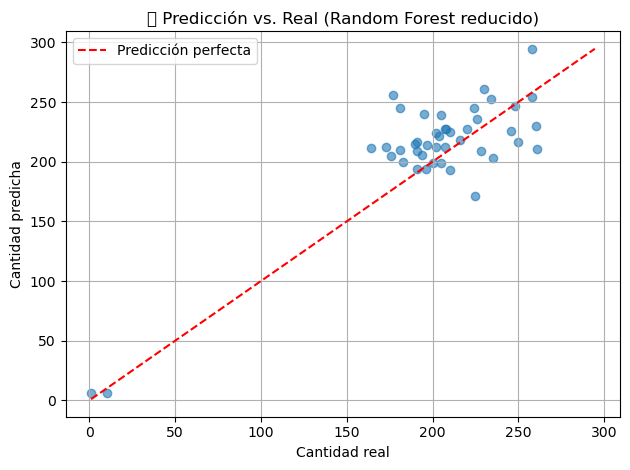

In [15]:
import matplotlib.pyplot as plt

max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Cantidad real")
plt.ylabel("Cantidad predicha")
plt.title("🎯 Predicción vs. Real (Random Forest reducido)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Guardar y mostrar
plt.savefig("pred_vs_real_rf_reducido.png")
plt.show()